<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - Project - Task</b></center>  
<pre>    

### Import Libraries 

In [9]:
import pandas as pd
import numpy as np

### Handle Missing Values

In [8]:
df = pd.read_csv("D:\\DEGREE\\sem-6\\ML\\Project\\Data\\cardio_train.csv",sep=";")

In [10]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [11]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


### Identify & Handle Outliers

In [12]:
#there is no outlier but unrealistic values (Medically Incorrect Values like ap_hi = 1000,0)
df = df[
    (df['height'] >= 120) & (df['height'] <= 220) &
    (df['weight'] >= 30) & (df['weight'] <= 200) &
    (df['ap_hi'] >= 80) & (df['ap_hi'] <= 250) &
    (df['ap_lo'] >= 40) & (df['ap_lo'] <= 200)
]

### Feature Engineering (Age Conversion)

In [13]:
df['age'].dtypes

dtype('int64')

In [14]:
df = df.copy()
df['age_years'] = (df['age'] / 365.25).astype(int)
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,52
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,61
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,52
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,61


### Normalize / Scale Numerical Features

In [17]:
df[num_cols] = df[num_cols].astype(float)

In [16]:
from sklearn.preprocessing import StandardScaler

num_cols = ['height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol','gluc']

scaler = StandardScaler()

df.loc[:, num_cols] = scaler.fit_transform(df[num_cols])

#cholescholesterol,glucz pn scaller ma convert krvani che
# imoprt kravi levamo che dataset and pchi ema bdhu apply krvanu che


C:\Users\binal\AppData\Local\Temp\ipykernel_21616\304724805.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.45302951 -1.06311438  0.07399354 ...  2.34820938 -0.17869711
  0.70572016]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, num_cols] = scaler.fit_transform(df[num_cols])
C:\Users\binal\AppData\Local\Temp\ipykernel_21616\304724805.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.99352543  0.79873712  0.20131627 ...  3.18842053  0.5000267
 -0.39610458]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, num_cols] = scaler.fit_transform(df[num_cols])
C:\Users\binal\AppData\Local\Temp\ipykernel_21616\304724805.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Valu

In [18]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,18393,2,0.453030,-0.847913,-0.993525,-0.142823,-0.537322,-0.395241,0,0,1,0,50
1,1,20228,1,-1.063114,0.760962,0.798737,0.892081,2.407873,-0.395241,0,0,1,1,55
2,2,18857,1,0.073994,-0.708010,0.201316,-1.177727,2.407873,-0.395241,0,0,0,1,51
3,3,17623,2,0.579375,0.551109,1.396158,1.926985,-0.537322,-0.395241,0,0,1,1,48
4,4,17474,1,-1.063114,-1.267619,-1.590946,-2.212631,-0.537322,-0.395241,0,0,0,0,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,0.453030,0.131402,-0.396105,-0.142823,-0.537322,-0.395241,1,0,1,0,52
69996,99995,22601,1,-0.810424,3.628957,0.798737,0.892081,0.935276,1.352898,0,0,1,1,61
69997,99996,19066,2,2.348209,2.159984,3.188421,0.892081,2.407873,-0.395241,0,1,0,1,52
69998,99998,22431,1,-0.178697,-0.148402,0.500027,-0.142823,-0.537322,1.352898,0,0,0,1,61


In [19]:
df.to_csv('cardio_train_cleaned.csv', index=False)

### Target Variable Distribution

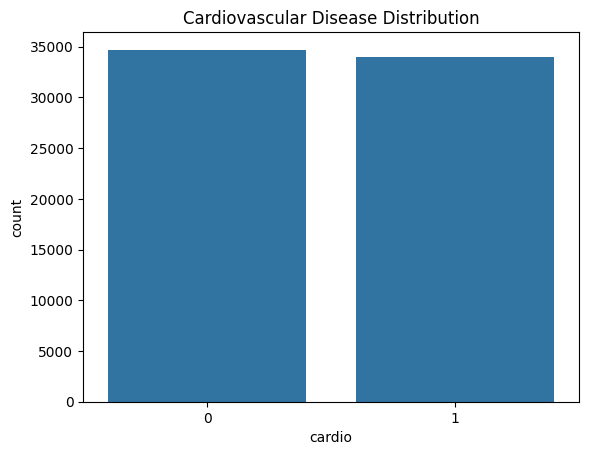

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='cardio', data=df)
plt.title("Cardiovascular Disease Distribution")
plt.show()


### Age vs Cardio

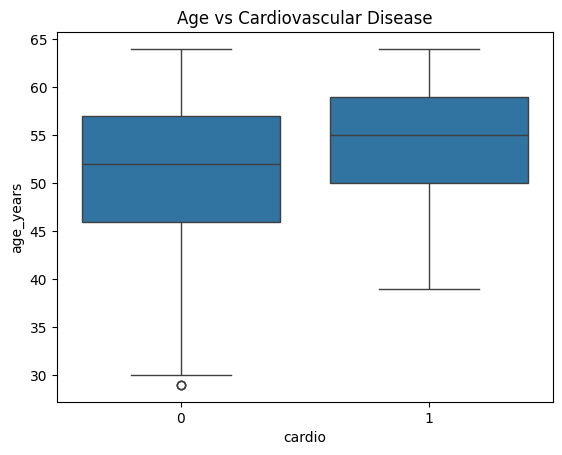

In [24]:
sns.boxplot(x='cardio', y='age_years', data=df)
plt.title("Age vs Cardiovascular Disease")
plt.show()


### Blood Pressure Analysis

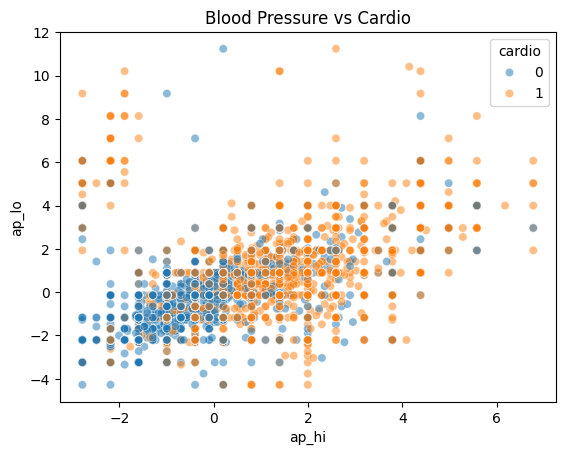

In [25]:
sns.scatterplot(x='ap_hi', y='ap_lo', hue='cardio', data=df, alpha=0.5)
plt.title("Blood Pressure vs Cardio")
plt.show()

### Cholesterol Impact

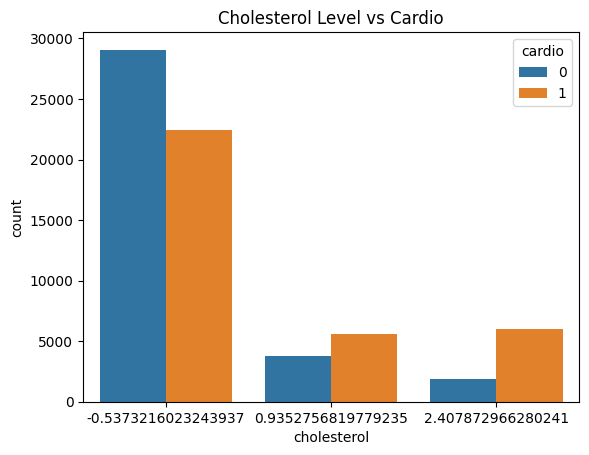

In [26]:
sns.countplot(x='cholesterol', hue='cardio', data=df)
plt.title("Cholesterol Level vs Cardio")
plt.show()

### Heat Map

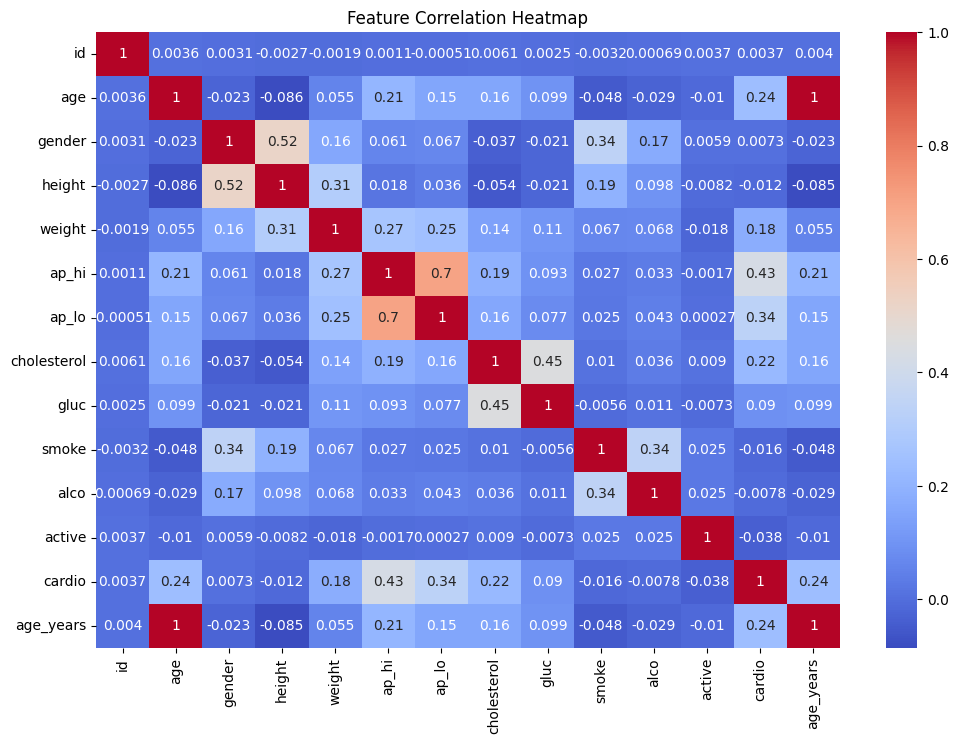

In [27]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()